In [1]:
from CADETProcess.processModel import ComponentSystem

component_system = ComponentSystem(['A', 'B'])

In [2]:
from CADETProcess.processModel import Langmuir

binding_model = Langmuir(component_system, name='langmuir')
binding_model.adsorption_rate = [0.04, 0.05]
binding_model.desorption_rate = [1, 1]
binding_model.capacity = [100, 100]

In [3]:
from CADETProcess.processModel import (
    Inlet, Cstr, LumpedRateModelWithoutPores, Outlet
)
feed = Inlet(component_system, name='feed')
feed.c = [10, 10]

eluent = Inlet(component_system, name='eluent')
eluent.c = [0, 0]

pump = Cstr(component_system, name='pump')
pump.V = 1e-9

column = LumpedRateModelWithoutPores(component_system, name='column')
column.binding_model = binding_model
column.length = 0.6
column.diameter = 0.024
column.axial_dispersion = 4.7e-7
column.total_porosity = 0.7

outlet = Outlet(component_system, name='outlet')

C:\Users\ezeiry\Documents\CADET-Process\CADETProcess\processModel\unitOperation.py:1498: UserWarning: The field V is only supported for backwards compatibility. Please set initial_liquid_volume and const_solid_volume.
  warnings.warn(


In [4]:
from CADETProcess.processModel import FlowSheet

flow_sheet = FlowSheet(component_system)

flow_sheet.add_unit(feed, feed_inlet=True)
flow_sheet.add_unit(eluent, eluent_inlet=True)
flow_sheet.add_unit(pump)
flow_sheet.add_unit(column)
flow_sheet.add_unit(outlet, product_outlet=True)

flow_sheet.add_connection(feed, column)
flow_sheet.add_connection(eluent, column)
flow_sheet.add_connection(column, outlet)
flow_sheet.add_connection(column, pump)
flow_sheet.add_connection(pump, column)

In [5]:
from CADETProcess.processModel import Process
process = Process(flow_sheet, 'clr')

In [6]:
Q = 60 / (60 * 1e6)

process.add_event('feed_on', 'flow_sheet.feed.flow_rate', Q)
process.add_event('feed_off', 'flow_sheet.feed.flow_rate', 0.0)

process.add_event('eluent_off', 'flow_sheet.eluent.flow_rate', 0.0)
process.add_event('eluent_on', 'flow_sheet.eluent.flow_rate', Q)

process.add_event('recycle_on_state', 'flow_sheet.output_states.column', {'pump': 1})
process.add_event('recycle_on_pump', 'flow_sheet.pump.flow_rate', Q)
process.add_event('recycle_off_state', 'flow_sheet.output_states.column', {'outlet': 1})
process.add_event('recycle_off_pump', 'flow_sheet.pump.flow_rate', 0)

Event(name=recycle_off_pump, parameter_path=flow_sheet.pump.flow_rate, state=0, time=0.0, indices=[(slice(None, None, None),)])

In [7]:
process.add_event_dependency('eluent_off', ['feed_on'])

process.add_event_dependency('recycle_on_state', ['feed_off'])
process.add_event_dependency('recycle_on_pump', ['feed_off'])

process.add_event_dependency('recycle_off_pump', ['recycle_off_state'])
process.add_event_dependency('eluent_on', ['recycle_off_state'])

In [8]:
process.cycle_time = 2000
process.feed_off.time = 40
process.recycle_off_state.time = 1280

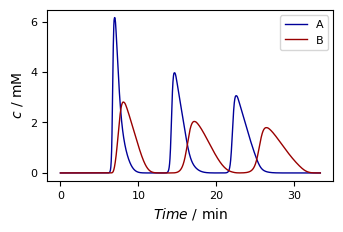

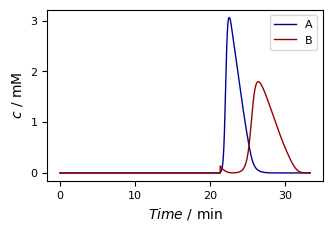

In [9]:
if __name__ == '__main__':
    from CADETProcess.simulator import Cadet
    process_simulator = Cadet()

    simulation_results = process_simulator.simulate(process)
    simulation_results.solution.column.outlet.plot()
    simulation_results.solution.outlet.inlet.plot()

In [10]:
if __name__ == '__main__':
    from CADETProcess.fractionation import FractionationOptimizer
    fractionation_optimizer = FractionationOptimizer()

    fractionator = fractionation_optimizer.optimize_fractionation(
        simulation_results, purity_required=[0.95, 0.95]
    )

    print(fractionator.performance)
    _ = fractionator.plot_fraction_signal()

[INFO 08-12 16:16:25] ax.storage.sqa_store.with_db_settings_base: Ax SQL storage initialized with SQLAlchemy 2.0.52


Performance(mass=array([0.00038245, 0.0003827 ]), concentration=array([1.70752855, 0.78508096]), purity=array([0.95904332, 0.95651775]), recovery=array([0.95612214, 0.95674708]), productivity=array([0.00234833, 0.00234986]), eluent_consumption=array([0.53117897, 0.53152615]) mass_balance_difference=array([-5.79820867e-09, -7.12298760e-08]))
